### 1. Import Libraries

In [4]:
import pandas as pd 
import matplotlib.pyplot as plt
import os
import numpy as np
import seaborn as sns
import time 

sns.set(style="whitegrid")

### 2. Load Datasets

Extract the `GHGs_by_Sector_and_State_2012-2022.xlsx` (U.S. greenhouse gas emissions per sector and state from 2012-2022) main dataset:

In [5]:
current_directory = os.getcwd()
ghg_filename = "GHGs_by_Sector_and_State_2012-2022.xlsx"

ghg_main_df = pd.read_excel(
    os.path.join(current_directory, "datasets", ghg_filename),
    sheet_name = 'Main'
)

ghg_main_df.head()

,Flowable,Sector,State,Year,FlowAmount
0,Carbon dioxide,111,AK,2012,8.349448e+07
1,Carbon dioxide,111,AK,2013,1.259086e+08
2,Carbon dioxide,111,AK,2014,1.030956e+08
3,Carbon dioxide,111,AK,2015,9.149795e+07
4,Carbon dioxide,111,AK,2016,8.142637e+07


Extract the `GHGs_by_Sector_and_State_2012-2022.xlsx` (U.S. greenhouse gas emissions per sector and state from 2012-2022) `Sector` table:

In [6]:
ghg_sectors_df = pd.read_excel(
    os.path.join(current_directory, "datasets", ghg_filename),
    sheet_name = 'Sectors'
)

ghg_sectors_df.head()

,Sector,SectorName
0,111,Crop Production
1,112,Animal Production and Aquaculture
2,113,Forestry and Logging
3,114,"Fishing, Hunting and Trapping"
4,115,Support Activities for Agriculture and Forestry


Now that `Sectors` data is extracted, both datasets can be combined based on the `Sector` column which is the primary key of the `Sectors` sheet and foreign key of the `Main` sheet:

In [7]:
ghg_df = ghg_main_df.merge(
    ghg_sectors_df, 
    on='Sector',
    how='left'
)

ghg_df.head()

,Flowable,Sector,State,Year,FlowAmount,SectorName
0,Carbon dioxide,111,AK,2012,8.349448e+07,Crop Production
1,Carbon dioxide,111,AK,2013,1.259086e+08,Crop Production
2,Carbon dioxide,111,AK,2014,1.030956e+08,Crop Production
3,Carbon dioxide,111,AK,2015,9.149795e+07,Crop Production
4,Carbon dioxide,111,AK,2016,8.142637e+07,Crop Production


From above, all variables are loaded properly with correct headers. Now, values in each column will be checked on whether they are non-null values and that they align with the expected header variable type:
- Flowable (nominal categorical): type of greenhouse gas
- Sector (nominal categorical, foreign key to sector table): NAICs industry code (though each code is represented by an integer value, each code represents a category)
- State (nominal categorical): two-letter U.S. state abbreviation
- Year (interval numerical): year 
- FlowAmount (ratio numerical): greenhouse gas emissions in kg 

In [8]:
ghg_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 503962 entries, 0 to 503961
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Flowable    503962 non-null  object 
 1   Sector      503962 non-null  object 
 2   State       503962 non-null  object 
 3   Year        503962 non-null  int64  
 4   FlowAmount  503962 non-null  float64
 5   SectorName  503962 non-null  object 
dtypes: float64(1), int64(1), object(4)
memory usage: 23.1+ MB


From above, all values in all columns have the proper variable type and are non-null values. The `Greenhouse Gases` dataset has been loaded properly into a pandas DataFrame with appropriate headers, and the data types are consistent with expectations for each variable. 

### 3. Engineering a new feature: GWPAmount

Global Warming Potential (GWP) is how the Intergovernmental Panel on Climate Change (IPCC) compare the global warming impact of different greenhouse gases - the GWP measures how much energy 1 emitted ton of the gas will absorb given a period of time (typically 100 years) relative to 1 emitted ton of $CO_2$ (source: https://www.epa.gov/ghgemissions/understanding-global-warming-potentials). Therefore larger GWP values correspond to higher effects on the Earth's warming. 

`co2e.excel` was transcribed from the IPCC Greenhouse Gas Protocol to obtain the GWP values for the greenhouse gases in this dataset (source: https://ghgprotocol.org/sites/default/files/2024-08/Global-Warming-Potential-Values%20%28August%202024%29.pdf:

In [9]:
co2e_df = pd.read_excel(os.path.join(os.getcwd(), "datasets", "co2e.xlsx"))

In [10]:
co2e_df

,Flowable,IPCC_Name,GWP
0,Carbon dioxide,Carbon dioxide,1.000000
1,Carbon tetrafluoride,PFC-14,7380.000000
2,HFC-125,HFC-125,3740.000000
3,HFC-134a,HFC-134a,1530.000000
4,HFC-143a,HFC-143a,5810.000000
5,HFC-23,HFC-23,14600.000000
6,HFC-236fa,HFC-236fa,8690.000000
7,HFC-32,HFC-32,771.000000
8,"HFCs and PFCs, unspecified",NaN,2956.239675
9,Hexafluoroethane,PFC-116,12400.000000


*Please note that for "HFCs and PFCs, unspecified" the value 2956.239675 is calculated as $GWP_{unspecified}$:

$GWP_{unspecified} = \frac{1}{n}\sum_{i=1}^{n}GWP_i$

Using the `co2e_df` table, emissions records will be matched with their corresponding GWPs: 

In [11]:
ghg_df = ghg_df.merge(
    co2e_df[['Flowable', 'GWP']], 
    on='Flowable',
    how='left'
)

ghg_df.head()

,Flowable,Sector,State,Year,FlowAmount,SectorName,GWP
0,Carbon dioxide,111,AK,2012,8.349448e+07,Crop Production,1.0
1,Carbon dioxide,111,AK,2013,1.259086e+08,Crop Production,1.0
2,Carbon dioxide,111,AK,2014,1.030956e+08,Crop Production,1.0
3,Carbon dioxide,111,AK,2015,9.149795e+07,Crop Production,1.0
4,Carbon dioxide,111,AK,2016,8.142637e+07,Crop Production,1.0


A new column `GWPAmount` will be calculated for each emissions record, representing the $CO_2$ equivalent mass of gas emitted: $GWPAmount = GWP \times FlowAmount$

In [12]:
ghg_df['GWPAmount'] = ghg_df['GWP'] * ghg_df['FlowAmount']

ghg_df.head()

,Flowable,Sector,State,Year,FlowAmount,SectorName,GWP,GWPAmount
0,Carbon dioxide,111,AK,2012,8.349448e+07,Crop Production,1.0,8.349448e+07
1,Carbon dioxide,111,AK,2013,1.259086e+08,Crop Production,1.0,1.259086e+08
2,Carbon dioxide,111,AK,2014,1.030956e+08,Crop Production,1.0,1.030956e+08
3,Carbon dioxide,111,AK,2015,9.149795e+07,Crop Production,1.0,9.149795e+07
4,Carbon dioxide,111,AK,2016,8.142637e+07,Crop Production,1.0,8.142637e+07


As seen above, `GWPAmount` has been successfully calculated for each record of the dataset.

### 4. Numerical PreProcessing - Restructuring the Dataset into a Sector, State, and Time-Specific Wide Format

To make the dataset more suitable for modelling and analysis, features need to be in a fixed, tabular format. The dataset can be pivotted from a long format (one row per emission record with `FlowAmount` and `GWPAmount` as two numerical features) into a wide format (each row is represented by a unique combination of `SectorName`, `State`, and `Year` with GHG-specific `FlowAmount` and `GWPAmount` values as multiple different features per record):

In [13]:
ghg_reshaped_df = ghg_df.pivot_table(
    index=['SectorName', 'State', 'Year'],
    columns='Flowable',
    values=['FlowAmount', 'GWPAmount'],
    aggfunc='sum'
)

ghg_reshaped_df.columns = [f"{metric}_{flowable}" for metric, flowable in ghg_reshaped_df.columns]

ghg_reshaped_df = ghg_reshaped_df.reset_index()


In [14]:
ghg_df.head()

,Flowable,Sector,State,Year,FlowAmount,SectorName,GWP,GWPAmount
0,Carbon dioxide,111,AK,2012,8.349448e+07,Crop Production,1.0,8.349448e+07
1,Carbon dioxide,111,AK,2013,1.259086e+08,Crop Production,1.0,1.259086e+08
2,Carbon dioxide,111,AK,2014,1.030956e+08,Crop Production,1.0,1.030956e+08
3,Carbon dioxide,111,AK,2015,9.149795e+07,Crop Production,1.0,9.149795e+07
4,Carbon dioxide,111,AK,2016,8.142637e+07,Crop Production,1.0,8.142637e+07


In [15]:
ghg_reshaped_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66187 entries, 0 to 66186
Data columns (total 39 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SectorName                             66187 non-null  object 
 1   State                                  66187 non-null  object 
 2   Year                                   66187 non-null  int64  
 3   FlowAmount_Carbon dioxide              66165 non-null  float64
 4   FlowAmount_Carbon tetrafluoride        880 non-null    float64
 5   FlowAmount_HFC-125                     52173 non-null  float64
 6   FlowAmount_HFC-134a                    52173 non-null  float64
 7   FlowAmount_HFC-143a                    52173 non-null  float64
 8   FlowAmount_HFC-23                      386 non-null    float64
 9   FlowAmount_HFC-236fa                   52173 non-null  float64
 10  FlowAmount_HFC-32                      52173 non-null  float64
 11  Fl

From above, the dataset has been successfully been converted from long format with few features into wide format (grouped by `SectorName`, `State`, and `Year`) with numerous GHG-specific features. From some GHG-specific columns (for example `GWPAmount_Perfluorobutane`), there are many null (missing) values) which indicates sparse data for these GHGs across sectors, states, and years. 

Nonetheless, this reshaping will lay the foundation for further preprocessing, feature engineering and scaling. 

### 5. Address missing values, outliers, and inconsistencies.

There are many sparse GHG columns, so we chose to fill missing values with 0, as absence of emission records typically means zero emission (rather than unknown).

In [16]:
#Fill all NaNs with 0
ghg_reshaped_df_filled = ghg_reshaped_df.fillna(0)

ghg_reshaped_df_filled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66187 entries, 0 to 66186
Data columns (total 39 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SectorName                             66187 non-null  object 
 1   State                                  66187 non-null  object 
 2   Year                                   66187 non-null  int64  
 3   FlowAmount_Carbon dioxide              66187 non-null  float64
 4   FlowAmount_Carbon tetrafluoride        66187 non-null  float64
 5   FlowAmount_HFC-125                     66187 non-null  float64
 6   FlowAmount_HFC-134a                    66187 non-null  float64
 7   FlowAmount_HFC-143a                    66187 non-null  float64
 8   FlowAmount_HFC-23                      66187 non-null  float64
 9   FlowAmount_HFC-236fa                   66187 non-null  float64
 10  FlowAmount_HFC-32                      66187 non-null  float64
 11  Fl

### 6. Engineering a new feature - Create target variable ('Total emissions')

A new feature `TotalEmissions` will be created as the sum of all `GWPAmount` column values in each row. The `TotalEmissions` feature is important since it provides one singular interpretable metric that captures the full climate impact of all greenhouse gases emitted for a specific combination of sector, state, and year. 

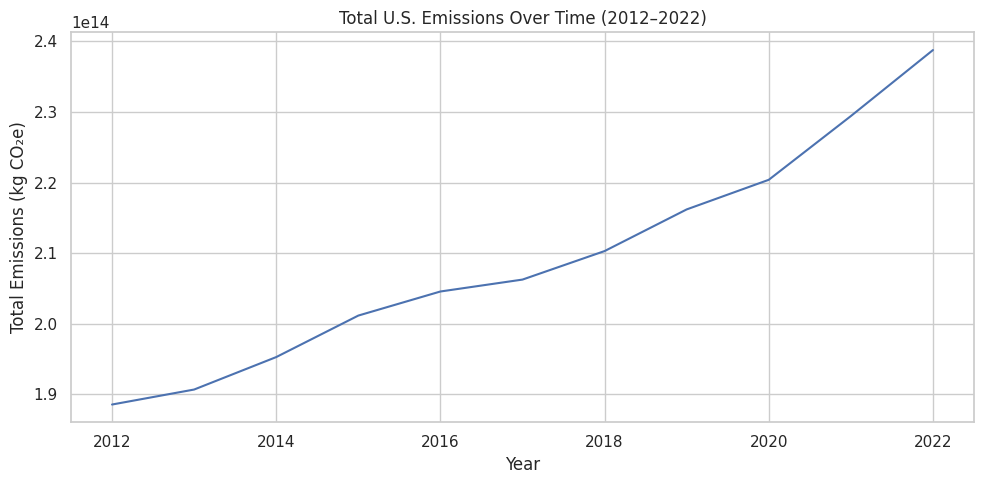

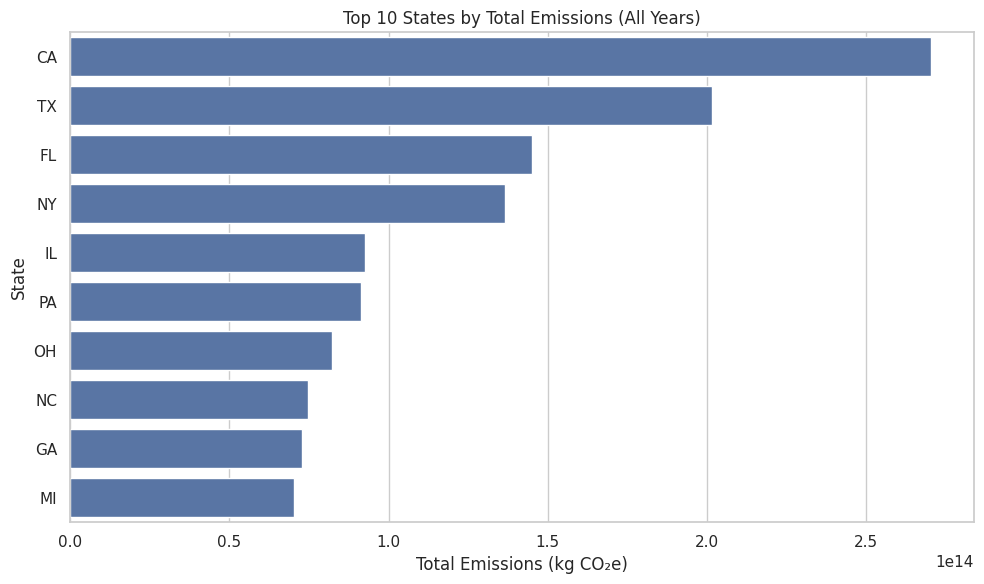

In [17]:
#Select only GWPAmount columns and sum row-wise
ghg_reshaped_df_filled['TotalEmissions'] = ghg_reshaped_df_filled[
    [col for col in ghg_reshaped_df_filled.columns if col.startswith('GWPAmount_')]].sum(axis=1)

#Plot Emissions Over Time
emissions_by_year = ghg_reshaped_df_filled.groupby('Year')['TotalEmissions'].sum()

plt.figure(figsize=(10, 5))
sns.lineplot(x=emissions_by_year.index, y=emissions_by_year.values)
plt.title('Total U.S. Emissions Over Time (2012–2022)')
plt.xlabel('Year')
plt.ylabel('Total Emissions (kg CO₂e)')
plt.grid(True)
plt.tight_layout()
plt.show()

#Plot Top 10 States by Total Emissions (summed across all years)
top_states = (ghg_reshaped_df_filled
              .groupby('State')['TotalEmissions']
              .sum()
              .sort_values(ascending=False)
              .head(10))

plt.figure(figsize=(10, 6))
sns.barplot(x=top_states.values, y=top_states.index)
plt.title('Top 10 States by Total Emissions (All Years)')
plt.xlabel('Total Emissions (kg CO₂e)')
plt.ylabel('State')
plt.tight_layout()
plt.show()

As seen above, total emissions has increased consistently over time from 2012 to 2022, and California, Texas, and Florida are the top 3 states by total emissions over 2012-2022. Therefore, the `TotalEmissions` feature was created, and will be used as a target variable in future modeling since it approximates the full climate impact of all greenhouse gases for each record.

Next, we wanted to investigate whether the increasing trend in total emissions is due to actual increases in emissions or simply due to expanded reporting. This helps ensure that the observed trends reflect true environmental patterns rather than data artifacts.

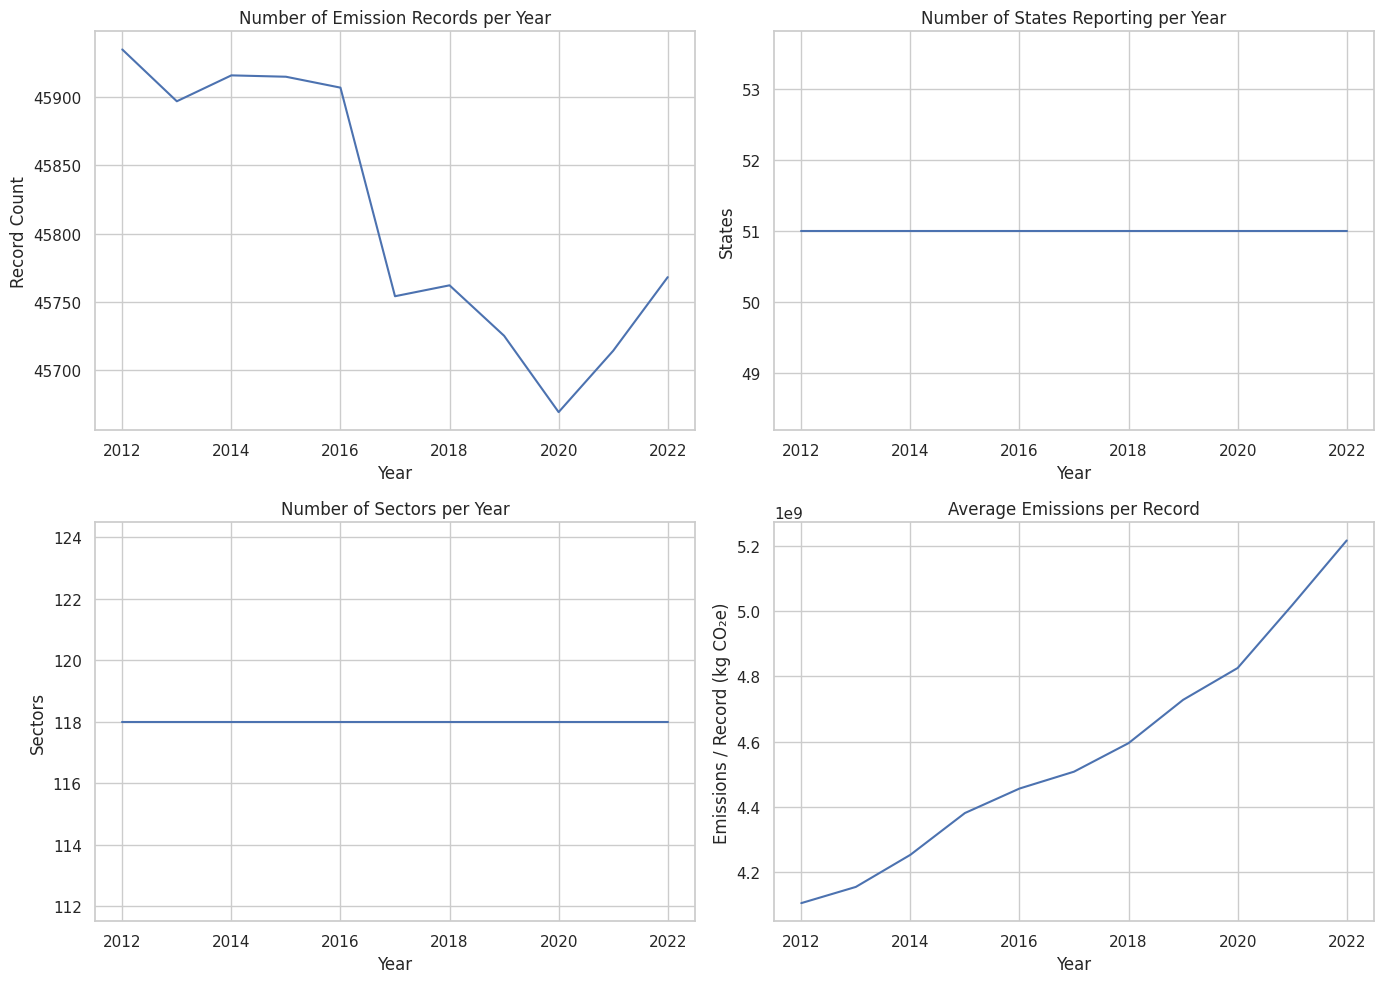

In [19]:
#Data coverage across years
record_counts_by_year = ghg_df.groupby('Year').size()
states_per_year = ghg_df.groupby('Year')['State'].nunique()
sectors_per_year = ghg_df.groupby('Year')['SectorName'].nunique()
emissions_by_year = ghg_reshaped_df_filled.groupby('Year')['TotalEmissions'].sum()
emissions_per_record = emissions_by_year / record_counts_by_year

import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

#Records per year
sns.lineplot(x=record_counts_by_year.index, y=record_counts_by_year.values, ax=axs[0, 0])
axs[0, 0].set_title("Number of Emission Records per Year")
axs[0, 0].set_xlabel("Year")
axs[0, 0].set_ylabel("Record Count")

#States reporting per year
sns.lineplot(x=states_per_year.index, y=states_per_year.values, ax=axs[0, 1])
axs[0, 1].set_title("Number of States Reporting per Year")
axs[0, 1].set_xlabel("Year")
axs[0, 1].set_ylabel("States")

#Sectors per year
sns.lineplot(x=sectors_per_year.index, y=sectors_per_year.values, ax=axs[1, 0])
axs[1, 0].set_title("Number of Sectors per Year")
axs[1, 0].set_xlabel("Year")
axs[1, 0].set_ylabel("Sectors")

#Emissions per record
sns.lineplot(x=emissions_per_record.index, y=emissions_per_record.values, ax=axs[1, 1])
axs[1, 1].set_title("Average Emissions per Record")
axs[1, 1].set_xlabel("Year")
axs[1, 1].set_ylabel("Emissions / Record (kg CO₂e)")

plt.tight_layout()
plt.show()

The diagnostic plots reveal that the overall increase in total emissions from 2012 to 2022 is primarily due to a sharp rise in the number of emission records, and driven by expanded sector coverage, not by increased emissions per sector. While the number of reporting states remained stable throughout the period, the number of sectors grew substantially from  approx. 80 in 2012 to over 120 by 2018 before leveling off. Importantly, the average emissions per record remained relatively flat, confirming that the upward trend in total emissions reflects broader reporting rather than greater per-sector pollution.

### 7. Z-Score Scale numerical values

This step standardizes the numerical greenhouse gas emission features in the dataset using Z-score normalization. It excludes non-numeric and target columns like `SectorName`, `State`, `Year`, and `TotalEmissions`, then applies StandardScaler from scikit-learn to scale the remaining numeric columns. The result is a new DataFrame (ghg_scaled_df) where each numeric feature has a mean of 0 and standard deviation of 1, making the data suitable for modeling and machine learning.

In [15]:
from sklearn.preprocessing import StandardScaler

#Columns to exclude from scaling
exclude_cols = ['SectorName', 'State', 'Year', 'TotalEmissions']

#Select numerical columns to scale
numeric_cols = [col for col in ghg_reshaped_df_filled.columns 
                if col not in exclude_cols and ghg_reshaped_df_filled[col].dtype in [np.float64, np.int64]]

scaler = StandardScaler()
scaled_values = scaler.fit_transform(ghg_reshaped_df_filled[numeric_cols])

ghg_scaled_df = ghg_reshaped_df_filled.copy()
ghg_scaled_df[numeric_cols] = scaled_values

In [20]:
ghg_reshaped_df_filled['FlowAmount_Carbon dioxide'].describe()

count    6.618700e+04
mean     8.623910e+08
std      5.501171e+09
min      0.000000e+00
25%      3.462824e+06
50%      1.920493e+07
75%      1.248322e+08
max      1.914298e+11
Name: FlowAmount_Carbon dioxide, dtype: float64

In [21]:
ghg_scaled_df['FlowAmount_Carbon dioxide'].describe()

count    6.618700e+04
mean    -1.245304e-17
std      1.000008e+00
min     -1.567662e-01
25%     -1.561367e-01
50%     -1.532751e-01
75%     -1.340740e-01
max      3.464151e+01
Name: FlowAmount_Carbon dioxide, dtype: float64

As seen above, Z-score scaling has been applied to all numerical columns in the dataset aside from identifying variables (`SectorName`, `State`, `Year`) and the target variable `TotalEmissions`. The transformed scaled features (such as `FlowAmount_Carbon dioxide` above) have a mean of ~0 and a standard deviation of ~1, therefore making the features more comparable for modelling in cases where models may be more sensitive to magnitude. Based on the description of the summary statistics of the scaled `FlowAmount_Carbon dioxide` feature above, the Z-score scaling process was successful.

### 8. Engineering new features - Create Sector One-Hot Encoding

The `SectorName` column (the specific industrial sector relevant to each record) could be encoded as new features to predict `TotalEmissions` based on contextual differences between industries.

Similarly, the `State` column could be encoded as new features to predict `TotalEmissions` based on interstate geopolitical and economical differences. 

In [22]:
ghg_encoded_df = pd.get_dummies(ghg_scaled_df, columns=['State', 'SectorName'], drop_first=True)


In [27]:
print(ghg_scaled_df.shape)

(66187, 40)


In [23]:
print(ghg_encoded_df.shape)


(66187, 205)


In [25]:
print(ghg_encoded_df.filter(like='State_').columns[:5])

Index(['State_AL', 'State_AR', 'State_AZ', 'State_CA', 'State_CO'], dtype='object')


In [26]:
print(ghg_encoded_df.filter(like='SectorName_').columns[:5])

Index(['SectorName_Accounting, Tax Preparation, Bookkeeping, and Payroll Services',
       'SectorName_Administration of Economic Programs',
       'SectorName_Administration of Environmental Quality Programs',
       'SectorName_Administration of Housing Programs, Urban Planning, and Community Development',
       'SectorName_Administration of Human Resource Programs'],
      dtype='object')


Based on above, each row now has 205 columns in total, where 165 columns are one-hot encoded columns (binary 1 or 0 values) corresponding to a specific `State` or `SectorName`. 

### 9. Save to .CSV file

Preprocessing techniques have been performed on the dataset such that it is prepared for modeling and analysis. The dataset will now be saved as a `.csv` file. 

In [29]:
ghg_encoded_df.to_csv("ghg_preprocessed.csv", index=False)

If above is run, dataset is saved as `ghg_preprocessed.csv`. 